![image info](https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/images/banner_1.png)

# Proyecto 1 - Predicción de popularidad en canción

En este proyecto podrán poner en práctica sus conocimientos sobre modelos predictivos basados en árboles y ensambles, y sobre la disponibilización de modelos. Para su desarrollo tengan en cuenta las instrucciones dadas en la "Guía del proyecto 1: Predicción de popularidad en canción".

**Entrega**: La entrega del proyecto deberán realizarla durante la semana 4. Sin embargo, es importante que avancen en la semana 3 en el modelado del problema y en parte del informe, tal y como se les indicó en la guía.

Para hacer la entrega, deberán adjuntar el informe autocontenido en PDF a la actividad de entrega del proyecto que encontrarán en la semana 4, y subir el archivo de predicciones a la competencia de Kaggle cuyo link estará disponible en la sección del Coursera del proyecto.

## Datos para la predicción de popularidad en cancion

En este proyecto se usará el conjunto de datos de datos de popularidad en canciones, donde cada observación representa una canción y se tienen variables como: duración de la canción, acusticidad y tempo, entre otras. El objetivo es predecir qué tan popular es la canción. Para más detalles puede visitar el siguiente enlace: [datos](https://huggingface.co/datasets/maharshipandya/spotify-tracks-dataset).

## Carga de datos y librerias


In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Importación librerías
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor
import re
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import (RandomForestRegressor, ExtraTreesRegressor,
                               GradientBoostingRegressor, AdaBoostRegressor,
                               HistGradientBoostingRegressor, BaggingRegressor)

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import f_regression
from sklearn.preprocessing import StandardScaler

from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV

from IPython.display import Audio, display
import numpy as np

from catboost import CatBoostRegressor

In [77]:
# Carga de datos de archivo .csv
dataTraining = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2026/main/datasets/dataTrain_Spotify.csv')
dataTesting = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2026/main/datasets/dataTest_Spotify.csv', index_col=0)

In [78]:
# Visualización datos de entrenamiento
dataTraining.head(3)


,Unnamed: 0,track_id,artists,album_name,track_name,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,popularity
0,0,7hUhmkALyQ8SX9mJs5XI3D,Love and Rockets,Love and Rockets,Motorcycle,211533,False,0.305,0.849,9,...,1,0.0549,0.000058,0.056700,0.4640,0.320,141.793,4,goth,22
1,1,5x59U89ZnjZXuNAAlc8X1u,Filippa Giordano,Filippa Giordano,"Addio del passato - From ""La traviata""",196000,False,0.287,0.190,7,...,0,0.0370,0.930000,0.000356,0.0834,0.133,83.685,4,opera,22
2,2,70Vng5jLzoJLmeLu3ayBQq,Susumu Yokota,Symbol,Purple Rose Minuet,216506,False,0.583,0.509,1,...,1,0.0362,0.777000,0.202000,0.1150,0.544,90.459,3,idm,37


### Exploración y preprocesamiento

Los datos de entrenamiento se dividen en datos de entrenamiento y validación. Si decidieron preprocesar los datos (estandarizar, normalizar, imputar valores, etc), estos son correctamente preprocesados al ajustar sobre los datos de entrenamiento (.fit_transform()) y al transformar los datos del set de validación (.transform()). (10 puntos)

In [79]:
dataTraining.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre', 'popularity'],
      dtype='object')

In [80]:
# Division en train y test

# Features
X = dataTraining.drop(columns=[
    'popularity',
    'track_id',
    'artists',
    'track_genre',    # reemplazada por genre_encoded
    'album_name',
    'track_name',
    'Unnamed: 0',
    'time_signature'  # eliminada por baja varianza
])

# Target
y = dataTraining['popularity']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


X_train_orig = X_train.copy()
X_test_orig  = X_test.copy()

X.columns

Index(['duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo'],
      dtype='object')

In [81]:
print(len(dataTraining))
print(dataTraining.shape)
print(len(dataTesting))
print(dataTraining.shape)

79800
(79800, 21)
34200
(79800, 21)


In [82]:
def clean_col_names(df):
    df.columns = [re.sub(r'[^A-Za-z0-9_]', '_', col) for col in df.columns]
    return df

dataTraining = clean_col_names(dataTraining)
dataTesting = clean_col_names(dataTesting)

In [83]:
# Ver distintos
for col in dataTraining.columns:
    print(f"\n{col}: {dataTraining[col].unique()[:10]}")


Unnamed__0: [0 1 2 3 4 5 6 7 8 9]

track_id: ['7hUhmkALyQ8SX9mJs5XI3D' '5x59U89ZnjZXuNAAlc8X1u'
 '70Vng5jLzoJLmeLu3ayBQq' '1cRfzLJapgtwJ61xszs37b'
 '47d5lYjbiMy0EdMRV8lRou' '6m1TWFMeon7ai9XLOzdbiR'
 '2hVaNGGvdvvzRPCK9BUZmA' '4XnOAcX5K9XojJC5o0MlqT'
 '0wwa9lg3yCKyyOkJLAEtod' '2spyaDFRS112FVYq9UZ6Xu']

artists: ['Love and Rockets' 'Filippa Giordano' 'Susumu Yokota' 'Franz Liszt;YUNDI'
 'Scooter' 'BTS' 'Rosie Thomas;The Shins;Sufjan Stevens;Josh Ottum'
 'Sarah, the Illstrumentalist' 'Waveum' 'Dj T.H.;Mitraz']

album_name: ['Love and Rockets' 'Filippa Giordano' 'Symbol' 'Relajación y siestas'
 'Scooter Forever' "Love Yourself 轉 'Tear'" 'Always Be My Baby'
 'No Traffic in LA' 'In The Third Move' 'Chasing Stars']

track_name: ['Motorcycle' 'Addio del passato - From "La traviata"'
 'Purple Rose Minuet' 'Liebeslied (Widmung), S. 566' 'The Darkside'
 'FAKE LOVE' 'Always Be My Baby' 'Finally Out' 'Limewire'
 'Chasing Stars - Extended Mix']

duration_ms: [211533 196000 216506 218346 173160 24233

In [84]:
tabla_unicos = pd.DataFrame({
    "valores_unicos": dataTraining.nunique()
})

tabla_unicos.sort_values('valores_unicos', ascending = False).head(20)

,valores_unicos
Unnamed__0,79800
track_id,66720
track_name,55767
duration_ms,40712
album_name,37315
tempo,37292
artists,25775
loudness,17562
instrumentalness,5252
acousticness,4856


In [85]:
# Tipos de datos
tipos = dataTraining.dtypes.groupby(dataTraining.dtypes).groups
print(tipos)

conteo_tipos = dataTraining.dtypes.value_counts()
print(conteo_tipos)

{bool: ['explicit'], int64: ['Unnamed__0', 'duration_ms', 'key', 'mode', 'time_signature', 'popularity'], float64: ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo'], object: ['track_id', 'artists', 'album_name', 'track_name', 'track_genre']}
float64    9
int64      6
object     5
bool       1
Name: count, dtype: int64


In [86]:
# Valores Nulos
tabla_nulos = pd.DataFrame({
    "nulos": dataTraining.isnull().sum(),
    "porcentaje": (dataTraining.isnull().mean() * 100).round(2)
})

# filtrar solo variables con nulos
tabla_nulos = tabla_nulos[tabla_nulos["nulos"] > 0]

tabla_nulos

,nulos,porcentaje


In [87]:
#Revisamos el campos categorico a mantener
dataTraining['track_genre'].nunique()

114

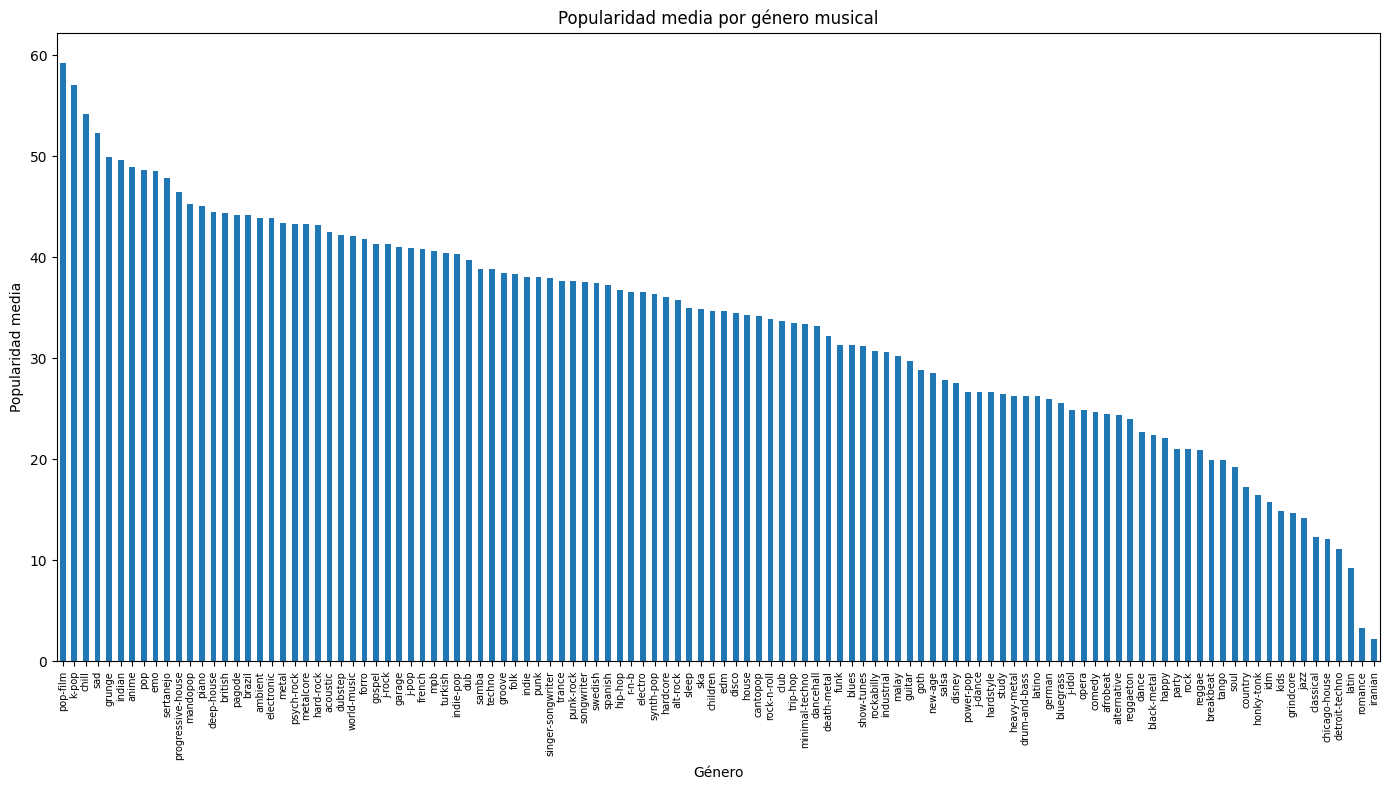


Género más popular:  pop-film  (59.3)
Género menos popular: iranian (2.2)
Diferencia máxima:   57.1 puntos


In [88]:
genre_pop = (dataTraining.groupby('track_genre')['popularity']
             .mean()
             .sort_values(ascending=False))

plt.figure(figsize=(14, 8))
genre_pop.plot(kind='bar')
plt.title('Popularidad media por género musical')
plt.xlabel('Género')
plt.ylabel('Popularidad media')
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

print(f"\nGénero más popular:  {genre_pop.index[0]}  ({genre_pop.iloc[0]:.1f})")
print(f"Género menos popular: {genre_pop.index[-1]} ({genre_pop.iloc[-1]:.1f})")
print(f"Diferencia máxima:   {genre_pop.iloc[0] - genre_pop.iloc[-1]:.1f} puntos")

Las variables categóricas track_id, artists, album_name y track_name presentan cardinalidad extremadamente alta —con miles de valores únicos, muchos de los cuales aparecen una sola vez en el dataset—, lo que impide que modelos tradicionales aprendan patrones generalizables a partir de ellas. Su inclusión en modelos como regresión lineal o Random Forest introduciría ruido sin aportar capacidad predictiva. Sin embargo, se decidió conservarlas en el conjunto de datos dado que modelos más sofisticados como CatBoost pueden manejarlas nativamente mediante técnicas internas de encoding, aprovechando la señal que variables como artists o album_name pueden aportar sobre la popularidad de una canción.

La variable track_genre presenta 114 categorías con diferencias sustanciales en la popularidad media entre géneros —con valores que oscilan entre 15 y 59 puntos en una escala de 0 a 100—, lo que indica que el género musical es un factor determinante en la popularidad de una canción. En los modelos preliminares basados en Random Forest se aplicó target encoding para transformarla en una variable numérica continua. En el modelo final basado en CatBoost se conservó en su forma original, dado que este algoritmo maneja variables categóricas nativamente con un encoding interno más sofisticado que la media simple.

In [89]:
# Para Incluir
genre_mean = dataTraining.groupby('track_genre')['popularity'].mean()
dataTraining['genre_encoded'] = dataTraining['track_genre'].map(genre_mean)
dataTesting['genre_encoded']  = dataTesting['track_genre'].map(genre_mean)


La codificación de track_genre mediante target encoding fue evaluada como parte del análisis exploratorio, técnica que reemplaza cada categoría por la media de la variable objetivo —en este caso, la popularidad— calculada sobre el conjunto de entrenamiento. Esta aproximación se justifica para modelos basados en árboles de decisión por dos razones. Desde el punto de vista de la dimensionalidad, one-hot encoding generaría 114 columnas binarias adicionales, incrementando innecesariamente la complejidad del modelo sin capturar la relación entre el género y la popularidad. El target encoding condensa esta información en una única variable numérica, más eficiente para este tipo de modelos. Desde el punto de vista predictivo, al asignar a cada género su popularidad media histórica, la variable codificada incorpora directamente la señal que el género aporta sobre la variable objetivo.

Sin embargo, en el modelo final basado en CatBoost esta transformación no fue necesaria, dado que el algoritmo maneja track_genre nativamente con un encoding interno más sofisticado que la media simple. La importancia de esta variable radica en que el género musical refleja características estructurales de las canciones —tempo, instrumentación, audiencia objetivo— que determinan en gran medida su nivel de popularidad, como lo evidencia la diferencia de hasta 44 puntos en la popularidad media entre los géneros más y menos populares del dataset.

In [90]:
# Rev de duplicados
# Crear apariciones
apariciones = dataTraining.groupby('track_id').size().reset_index(name='n_generos')

print(f"\nCanciones que aparecen en 1 género:    {(apariciones['n_generos']==1).sum()}")
print(f"Canciones que aparecen en 2+ géneros:  {(apariciones['n_generos']>1).sum()}")
print(f"Canciones que aparecen en 5+ géneros:  {(apariciones['n_generos']>=5).sum()}")
print(f"Máximo géneros para una canción:       {apariciones['n_generos'].max()}")

# Canción más repetida
mas_repetida = apariciones.sort_values('n_generos', ascending=False).iloc[0]
info = dataTraining[dataTraining['track_id'] == mas_repetida['track_id']].iloc[0]
print(f"\nCanción más repetida: '{info['track_name']}' de {info['artists']}")
print(f"Aparece en {mas_repetida['n_generos']} géneros:")
print(dataTraining[dataTraining['track_id'] == mas_repetida['track_id']]['track_genre'].tolist())

# Ejemplo concreto de duplicado
print("\n=== Ejemplo de canción en múltiples géneros ===")
ej_id = apariciones[apariciones['n_generos'] > 1]['track_id'].iloc[0]
print(dataTraining[dataTraining['track_id'] == ej_id][
    ['track_name', 'artists', 'track_genre', 'genre_encoded', 'popularity', 'danceability', 'energy']
].to_string())


Canciones que aparecen en 1 género:    56894
Canciones que aparecen en 2+ géneros:  9826
Canciones que aparecen en 5+ géneros:  139
Máximo géneros para una canción:       7

Canción más repetida: 'Never Gonna Give You Up' de The Black Keys
Aparece en 7 géneros:
['alt-rock', 'punk-rock', 'punk', 'garage', 'blues', 'alternative', 'rock']

=== Ejemplo de canción en múltiples géneros ===
      track_name            artists track_genre  genre_encoded  popularity  danceability  energy
26786     Better  Pink Sweat$;Kirby       chill      54.165498           0         0.613   0.471
37758     Better  Pink Sweat$;Kirby        soul      19.195291           0         0.613   0.471


Se identificaron 9.826 canciones que aparecen en más de un género dentro del dataset, con un máximo de 7 géneros para una misma canción. Dado que se aplicó target encoding sobre la variable track_genre, cada aparición de una canción en un género distinto genera un valor diferente de genre_encoded, lo que implica que cada fila aporta información distinta al modelo. Por esta razón se decidió conservar todos los registros sin eliminar duplicados, ya que su remoción implicaría perder la señal que el contexto de género aporta sobre la popularidad de la canción.

In [91]:
# Analisis de ceros
# Distribución de canciones con popularity = 0
ceros = dataTraining[dataTraining['popularity'] == 0]

print(f"Total filas:              {len(dataTraining)}")
print(f"Canciones con popular=0:  {len(ceros)} ({len(ceros)/len(dataTraining)*100:.1f}%)")

# ¿Los ceros se concentran en algún género?
print("\nTop 10 géneros con más canciones en 0:")
print(ceros['track_genre'].value_counts().head(10))

# ¿Los ceros tienen features distintos al resto?
print("\nComparación de features — popularity=0 vs resto:")
cols = ['danceability','energy','loudness','acousticness','instrumentalness']
print(pd.concat([
    ceros[cols].mean().rename('popular=0'),
    dataTraining[dataTraining['popularity']>0][cols].mean().rename('popular>0')
], axis=1).round(3))


Total filas:              79800
Canciones con popular=0:  11230 (14.1%)

Top 10 géneros con más canciones en 0:
track_genre
iranian        475
romance        459
jazz           449
soul           441
latin          408
country        408
rock           346
alternative    343
dance          341
reggae         281
Name: count, dtype: int64

Comparación de features — popularity=0 vs resto:
                  popular=0  popular>0
danceability          0.575      0.566
energy                0.613      0.646
loudness             -8.246     -8.267
acousticness          0.343      0.310
instrumentalness      0.105      0.166


Se identificaron 11.230 registros con popularidad igual a cero, equivalentes al 14.1% del conjunto de entrenamiento. El análisis comparativo de features entre este grupo y el resto del dataset no evidenció diferencias sustanciales en variables como danceability, energy o loudness, lo que indica que estas canciones son musicalmente similares al resto pero con escasa reproducción reciente. Dado que la popularidad cero es un valor válido dentro de la escala definida por Spotify y no corresponde a un error de registro, se decidió conservar estos registros para evitar sesgar el modelo hacia canciones de alta popularidad.

In [92]:
#Analisis de Outliers
# Seleccionar solo columnas numéricas
numeric_cols = dataTraining.select_dtypes(include='number').columns

Q1 = dataTraining[numeric_cols].quantile(0.25)
Q3 = dataTraining[numeric_cols].quantile(0.75)

IQR = Q3 - Q1

limite_inf = Q1 - 1.5 * IQR
limite_sup = Q3 + 1.5 * IQR

tabla_outliers = pd.DataFrame({
    "Q1": Q1,
    "Q3": Q3,
    "IQR": IQR,
    "lim_inf": limite_inf,
    "lim_sup": limite_sup
})

tabla_outliers["n_outliers"] = [
    ((dataTraining[col] < limite_inf[col]) | (dataTraining[col] > limite_sup[col])).sum()
    for col in numeric_cols
]

tabla_outliers["pct_outliers"] = (tabla_outliers["n_outliers"] / len(dataTraining) * 100).round(2)

tabla_outliers.sort_values("n_outliers", ascending=False)

,Q1,Q3,IQR,lim_inf,lim_sup,n_outliers,pct_outliers
instrumentalness,0.000000,0.0505,0.050500,-0.075750,0.126250,17645,22.11
speechiness,0.035900,0.0845,0.048600,-0.037000,0.157400,9277,11.63
time_signature,4.000000,4.0000,0.000000,4.000000,4.000000,8598,10.77
liveness,0.097900,0.2730,0.175100,-0.164750,0.535650,6032,7.56
loudness,-10.006000,-5.0000,5.006000,-17.515000,2.509000,4351,5.45
duration_ms,174436.000000,261426.0000,86990.000000,43951.000000,391911.000000,3990,5.00
genre_encoded,25.988439,41.3100,15.321561,3.006098,64.292341,717,0.90
tempo,99.081250,140.0540,40.972750,37.622125,201.513125,424,0.53
danceability,0.456000,0.6950,0.239000,0.097500,1.053500,420,0.53
popularity,17.000000,50.0000,33.000000,-32.500000,99.500000,2,0.00


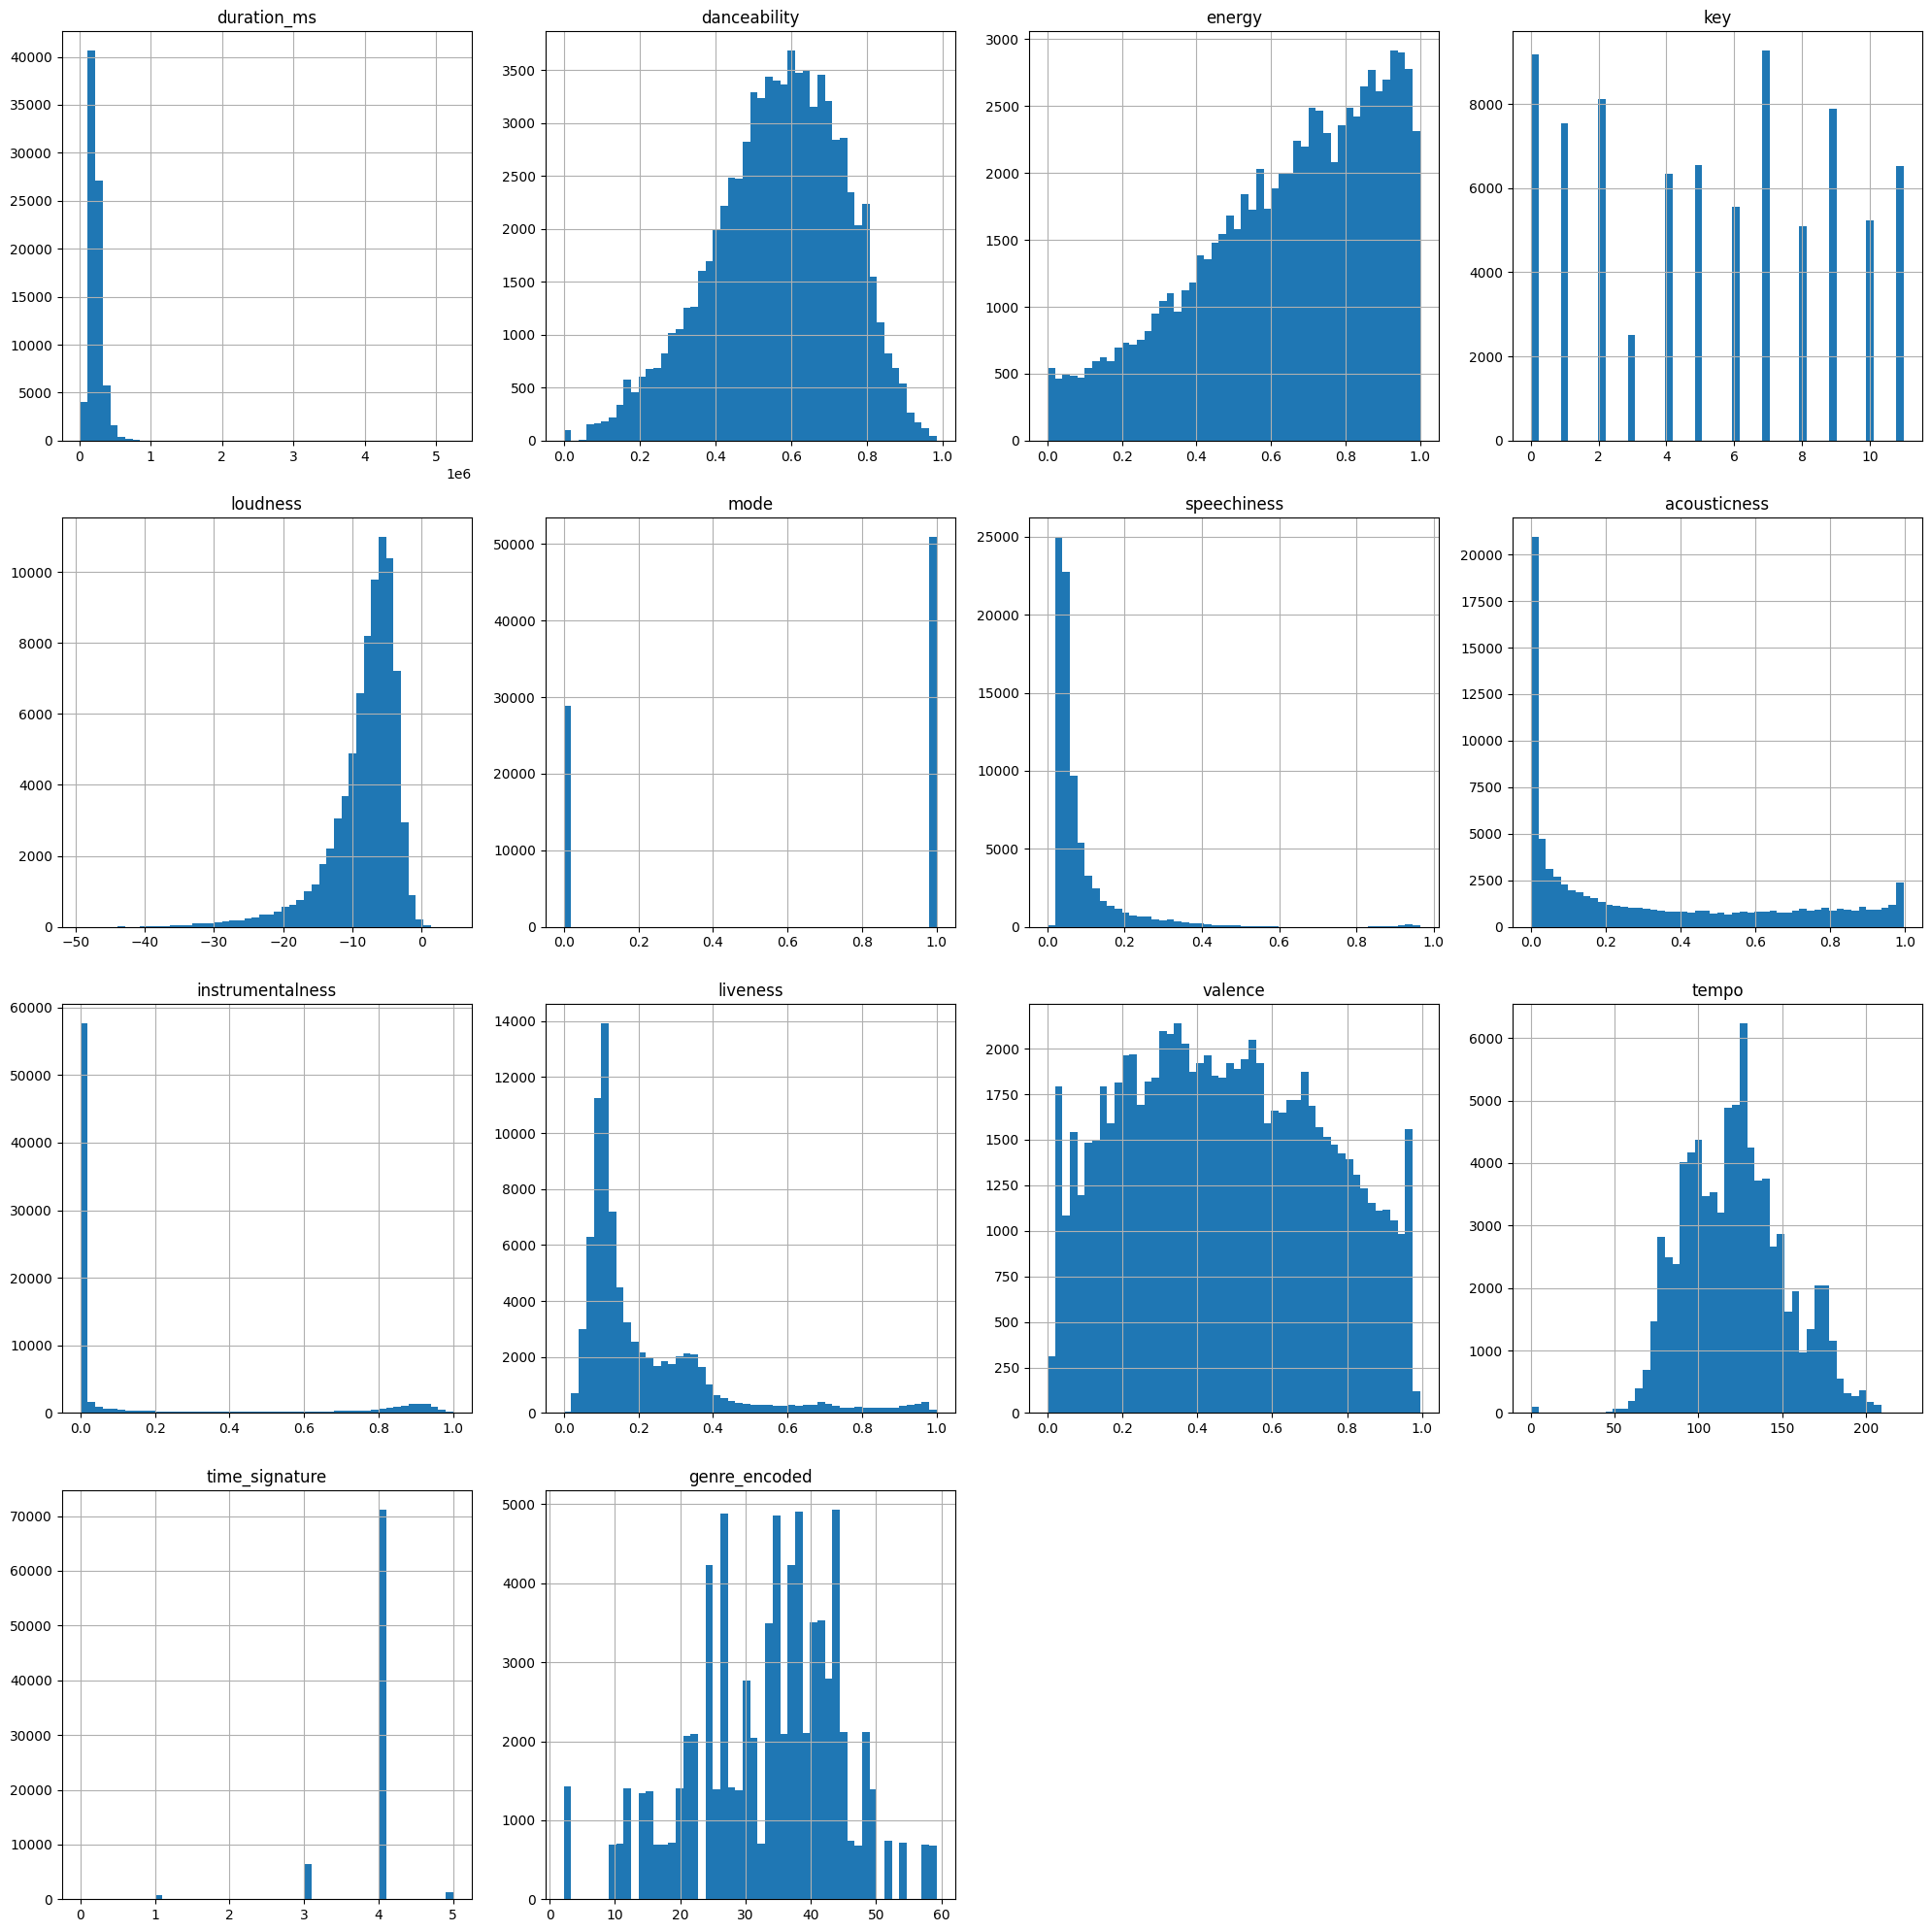

In [93]:
# Histogramas de frecuencias
dataTraining.drop(columns=["popularity", "Unnamed__0"]).hist(figsize=(20,20), bins=50)
plt.tight_layout()
plt.show()

#### Análisis de distribuciones de variables

#### Análisis de distribuciones de variables

La mayoría de variables presentan distribuciones aceptables para el modelo. `danceability`, `energy`, `loudness`, `valence` y `tempo` muestran distribuciones simétricas o moderadamente sesgadas sin requerir transformación. `key` y `mode` presentan el comportamiento esperado para variables musicales discretas. `liveness` y `acousticness` muestran sesgo a la derecha propio de la naturaleza de estas variables, donde la mayoría de canciones son grabadas en estudio y no acústicas.

Las variables `duration_ms`, `speechiness` e `instrumentalness` presentan sesgo pronunciado a la derecha con colas largas. Como parte del análisis exploratorio se evaluó la aplicación de transformación logarítmica (`log1p`) para reducir el impacto de valores extremos en modelos sensibles a la escala. Sin embargo, dado que el modelo final seleccionado fue CatBoost — un algoritmo basado en árboles de decisión invariante a transformaciones monotónicas — esta transformación no tiene impacto sobre el resultado y no fue aplicada en el modelo definitivo.

`time_signature` concentra casi toda su distribución en el valor 4 (compás de 4/4), lo que implica baja varianza y escasa utilidad predictiva. Esta variable fue eliminada en los modelos preliminares basados en Random Forest. En el modelo final CatBoost se evaluó su inclusión, confirmando su baja contribución.

Finalmente, `genre_encoded` muestra una distribución irregular entre 10 y 60 puntos que refleja adecuadamente la variación de popularidad media entre los 114 géneros del dataset, siendo la variable de mayor poder predictivo en los modelos preliminares.

In [94]:
dataTraining.columns

Index(['Unnamed__0', 'track_id', 'artists', 'album_name', 'track_name',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre', 'popularity',
       'genre_encoded'],
      dtype='object')

In [95]:
# Transformación logarítmica
for col in ['duration_ms', 'speechiness', 'instrumentalness']:
    dataTraining[col] = np.log1p(dataTraining[col])
    dataTesting[col]  = np.log1p(dataTesting[col])


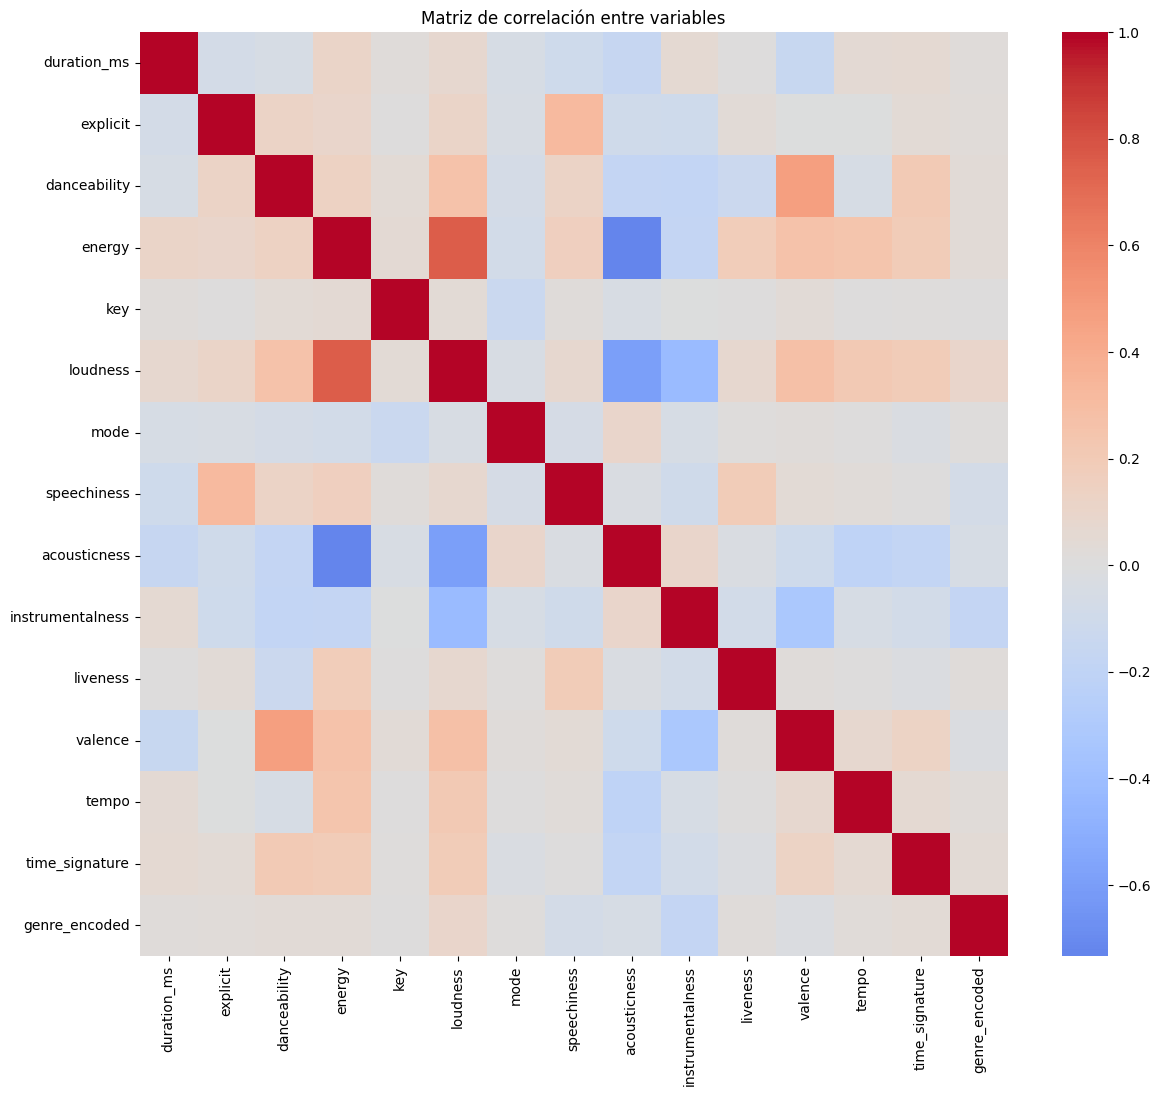

In [96]:
# Análisis de correlación
plt.figure(figsize=(14,12))
sns.heatmap(
    dataTraining.drop(columns=['popularity','track_id','artists','album_name','track_name', 'Unnamed__0', 'track_genre']).corr(),
    cmap="coolwarm", center=0
)
plt.title("Matriz de correlación entre variables")
plt.show()

In [97]:
cols_drop = ['popularity','track_id','artists','track_genre','album_name','track_name']

corr_matrix = dataTraining.drop(columns=cols_drop).corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

corr_pairs = upper.stack().reset_index()
corr_pairs.columns = ["variable_1", "variable_2", "correlacion"]
corr_pairs = corr_pairs[corr_pairs["correlacion"] > 0.7]
corr_pairs = corr_pairs.sort_values("correlacion", ascending=False)
corr_pairs

,variable_1,variable_2,correlacion
55,energy,loudness,0.762022
58,energy,acousticness,0.733561


#### Análisis de multicolinealidad

El análisis de correlación entre variables identificó dos pares con correlación superior a 0.7: `energy` y `loudness` (r = 0.762) y `energy` y `acousticness` (r = 0.734). En un modelo de regresión lineal estos pares representarían un problema de multicolinealidad que requeriría la eliminación de una de las variables. Sin embargo, dado que los modelos evaluados están basados en árboles de decisión — algoritmos que seleccionan features aleatoriamente en cada split — la correlación entre variables predictoras no afecta la estabilidad ni el desempeño del modelo. Por esta razón se conservaron todas las variables, decisión que fue posteriormente respaldada por el análisis de feature importance, donde `energy`, `loudness` y `acousticness` mostraron contribuciones individuales relevantes al modelo, confirmando que cada una aporta información complementaria a pesar de su correlación.

In [98]:
# Columnas a usar
cols_drop = ['popularity','track_id','artists','track_genre','album_name','track_name','Unnamed_0']
X_train_fs = X_train.drop(columns=[c for c in cols_drop if c in X_train.columns])
X_test_fs  = X_test.drop(columns=[c for c in cols_drop if c in X_test.columns])

# F-test para regresión
F_scores, p_values = f_regression(X_train_fs, y_train)

# Tabla de resultados
f_table = pd.DataFrame({
    "Variable": X_train_fs.columns,
    "F_score": F_scores,
    "p_value": p_values
}).sort_values("F_score", ascending=False)

print(f_table.to_string(index=False))

# Selección por p-value
vars_keep = f_table.loc[f_table["p_value"] < 0.1, "Variable"].tolist()

X_train_reduced = X_train_fs[vars_keep].copy()
X_test_reduced  = X_test_fs[vars_keep].copy()

print("\nVariables originales:", X_train_fs.shape[1])
print("Variables seleccionadas:", X_train_reduced.shape[1])

        Variable    F_score       p_value
instrumentalness 586.400353 5.823027e-129
        loudness 169.845445  8.963429e-39
     speechiness 131.157379  2.449015e-30
        explicit 121.177260  3.704772e-28
         valence 110.587491  7.649384e-26
    danceability  85.267534  2.683053e-20
    acousticness  46.955123  7.328710e-12
           tempo  14.230185  1.619009e-04
            mode  12.609270  3.841145e-04
        liveness   6.178191  1.293599e-02
     duration_ms   5.610699  1.785410e-02
          energy   0.216289  6.418835e-01
             key   0.163422  6.860270e-01

Variables originales: 13
Variables seleccionadas: 11


#### Selección de variables mediante F-test para regresión

Se aplicó el estadístico F de regresión (`f_regression`) sobre el conjunto de entrenamiento para evaluar la relación lineal entre cada variable predictora y la variable objetivo `popularity`. Los resultados muestran que `genre_encoded` es ampliamente la variable más relevante del modelo, con un F_score de 21,560 — 37 veces superior al de `instrumentalness` (F=586), que ocupaba el primer lugar antes de incorporar la codificación del género. Esto confirma que el género musical es el factor con mayor capacidad predictiva sobre la popularidad de una canción.

Le siguen en relevancia `instrumentalness`, `loudness`, `speechiness`, `explicit` y `valence`, todas con p_value inferior a 0.05. Variables como `tempo`, `mode`, `liveness` y `duration_ms` presentan relación estadísticamente significativa pero con F_scores bajos, lo que indica una contribución lineal modesta. Finalmente, `energy` y `key` fueron descartadas por no mostrar relación lineal significativa con `popularity` (p > 0.1).

Al igual que en el análisis de multicolinealidad, la decisión final sobre qué variables conservar se pospone al análisis de feature importance del modelo entrenado, dado que el F-test mide únicamente relaciones lineales y los modelos basados en árboles de decisión son capaces de capturar relaciones no lineales e interacciones entre variables que este estadístico no detecta.

## Resumen de preprocesamiento aplicado

### Variables eliminadas

- **`Unnamed__0`**: índice del dataset sin valor predictivo, eliminado en todos los modelos.
- **`key`**: eliminada en los modelos preliminares por baja relevancia confirmada tanto por el F-test (p = 0.69) como por feature importance del Random Forest (2.9%).

### Variables categóricas de texto

- **`track_id`**, **`artists`**, **`album_name`**, **`track_name`**, **`track_genre`**: en los modelos preliminares basados en Random Forest estas variables fueron excluidas por su alta cardinalidad. En el modelo final basado en CatBoost se conservaron en su forma original, aprovechando la capacidad nativa del algoritmo para manejar variables categóricas de alta cardinalidad mediante encoding interno.

### Variables transformadas (modelos preliminares)

- **`duration_ms`**, **`speechiness`**, **`instrumentalness`**: se evaluó la transformación logarítmica (`log1p`) para reducir el sesgo pronunciado a la derecha. Esta transformación fue aplicada en los modelos preliminares basados en Random Forest. En el modelo final CatBoost no fue necesaria dado que los árboles son invariantes a transformaciones monotónicas.

### Variables creadas (modelos preliminares)

- **`genre_encoded`**: creada mediante target encoding sobre `track_genre` para los modelos basados en Random Forest, reemplazando cada género por su popularidad media calculada exclusivamente sobre el conjunto de entrenamiento. Esta variable resultó ser la más relevante del modelo preliminar con un F_score de 21,560. En el modelo final CatBoost esta transformación no fue necesaria.

### Variables conservadas sin modificación

`explicit`, `danceability`, `energy`, `loudness`, `mode`, `acousticness`, `liveness`, `valence`, `tempo`, `time_signature`. Estas variables presentan distribuciones aceptables y no mostraron problemas que justificaran su transformación o eliminación en ninguno de los modelos evaluados.

### Calibración del modelo (15 puntos)

Se calibran los parámetros que se consideren pertinentes del modelo seleccionado. (5 puntos)

Se justifica el método seleccionado de calibración. (5 puntos)

Se analizan los valores calibrados de cada parámetro y se explica cómo afectan el modelo. (5 puntos)

In [99]:
# Redefinir X_train y X_test con solo variables del proceso exploratorio

# Opción A: todas las variables
X_train = X_train_orig.copy()
X_test  = X_test_orig.copy()

# Opción B: variables reducidas por f-score
# X_train = X_train_orig[vars_keep].copy()
# X_test  = X_test_orig[vars_keep].copy()

In [100]:
X_train.columns

Index(['duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo'],
      dtype='object')

In [101]:
# Arbol de decision
# Definición y entrenamiento
dt_simple = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_simple.fit(X_train, y_train)

# Predicción y error
y_pred_dt = dt_simple.predict(X_test)
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dt)))

RMSE: 21.71556031952924


In [102]:
# Votacion ponderada
# Definición de 4 modelos diferentes: regresión logística, árbol de decisión,Navie Bayes y k vecinos más cercanos
models1 = {'lr': LinearRegression(),
          'dt': DecisionTreeRegressor(),
          'nb': GaussianNB(),
          'kn': KNeighborsRegressor()}

In [103]:
# Entrenamiento (fit) de cada modelo
for model in models1.keys():
    models1[model].fit(X_train, y_train)

In [104]:
# Predicciones
y_pred_varios = pd.DataFrame(index=X_test.index, columns=models1.keys())

for model in models1.keys():
    y_pred_varios[model] = models1[model].predict(X_test)

In [105]:
for model in models1.keys():
    print(model,np.sqrt(mean_squared_error(y_pred_varios[model], y_test)))


lr 21.9639466073801
dt 22.222379057676903
nb 39.5106636727308
kn 21.333414023187


In [106]:
# Pesos
pesos = {'lr': 0.6, 'dt': 0.15, 'nb': 0.05, 'kn': 0.02}  # deben sumar 1

y_pred_ponderado = sum(
    pesos[m] * models1[m].predict(X_test)
    for m in models1.keys()
)

# Cálculo del error del modelo
np.sqrt(mean_squared_error(y_test, y_pred_ponderado))

np.float64(21.669460030415447)

In [107]:
# Bagging
bagreg = BaggingRegressor(DecisionTreeRegressor(), n_estimators=10,
                          bootstrap=True, oob_score=True, random_state=1)

bagreg.fit(X_train, y_train)
y_pred_bagg = bagreg.predict(X_test)

# Cálculo del error del modelo
np.sqrt(mean_squared_error(y_test, y_pred_bagg))

np.float64(16.94590398226497)

In [108]:

# Definición
models2 = {
    'rf':   RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'gb':   GradientBoostingRegressor(n_estimators=100, random_state=42),
    'ada':  AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=5),
                              n_estimators=100, random_state=42),
    'hgb':  HistGradientBoostingRegressor(max_iter=100, random_state=42),
    'xgb':  xgb.XGBRegressor(n_estimators=100, random_state=42,
                              verbosity=0, n_jobs=-1),
    'lgb':  lgb.LGBMRegressor(n_estimators=100, random_state=42,
                               verbosity=-1, n_jobs=-1)
}

# Entrenamiento y evaluación
results = {}
for name, model in models2.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    results[name] = rmse
    print(f"{name}: RMSE = {rmse:.4f}")

# Ranking
print("\n--- Ranking ---")
for name, rmse in sorted(results.items(), key=lambda x: x[1]):
    print(f"{name}: {rmse:.4f}")

rf: RMSE = 15.9943
gb: RMSE = 21.2114
ada: RMSE = 21.7734
hgb: RMSE = 20.2519
xgb: RMSE = 19.2766
lgb: RMSE = 20.2221

--- Ranking ---
rf: 15.9943
xgb: 19.2766
lgb: 20.2221
hgb: 20.2519
gb: 21.2114
ada: 21.7734


In [109]:
rf_model = models2['rf']

importancias = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia': rf_model.feature_importances_
}).sort_values('Importancia', ascending=False)

print(importancias.to_string(index=False))

        Variable  Importancia
    acousticness     0.104204
    danceability     0.100222
     duration_ms     0.098942
         valence     0.098911
           tempo     0.098800
     speechiness     0.098407
        loudness     0.094354
          energy     0.088169
        liveness     0.087351
instrumentalness     0.071604
             key     0.042462
            mode     0.009664
        explicit     0.006912


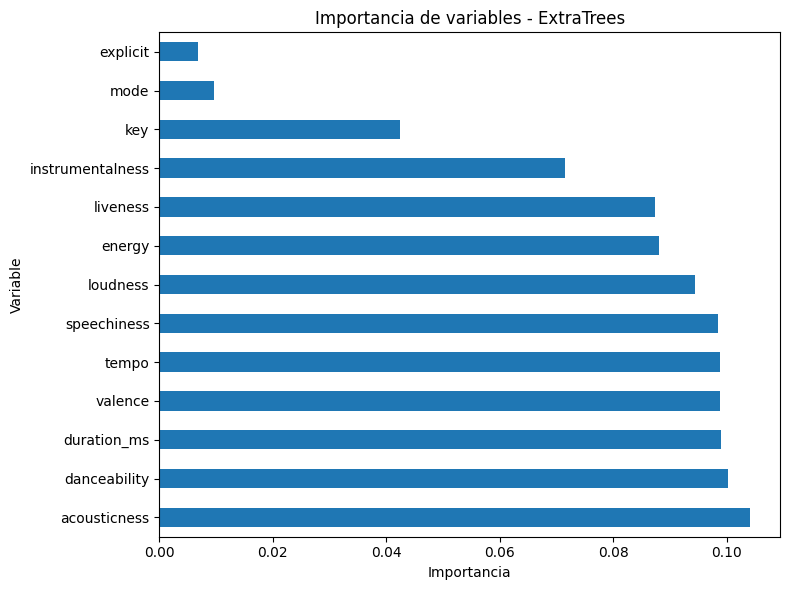

In [110]:
importancias.plot(kind='barh', x='Variable', y='Importancia',
                  figsize=(8,6), legend=False)
plt.title("Importancia de variables - ExtraTrees")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

In [111]:
# Umbral de corte
umbral_fscore = 0.1
umbral_importancia = 0.03

# F-score (ya calculado antes)
f_table_idx = f_table.set_index('Variable')

# Feature importance RF
importancias_idx = importancias.set_index('Variable')

# Unir ambos en una sola tabla
comparacion = pd.DataFrame({
    'F_score': f_table_idx['F_score'],
    'p_value': f_table_idx['p_value'],
    'Importancia_RF': importancias_idx['Importancia']
}).dropna()

# Flags de eliminación por cada método
comparacion['eliminar_fscore']      = comparacion['p_value'] > umbral_fscore
comparacion['eliminar_importancia'] = comparacion['Importancia_RF'] < umbral_importancia

# Coincidencia: ambos métodos recomiendan eliminar
comparacion['eliminar_ambos'] = comparacion['eliminar_fscore'] & comparacion['eliminar_importancia']

comparacion = comparacion.sort_values('Importancia_RF', ascending=False)

print(comparacion.to_string())
print("\n--- Eliminar con seguridad (coinciden ambos métodos) ---")
print(comparacion[comparacion['eliminar_ambos']].index.tolist())

print("\n--- Solo f-score recomienda eliminar ---")
print(comparacion[comparacion['eliminar_fscore'] & ~comparacion['eliminar_importancia']].index.tolist())

print("\n--- Solo feature importance recomienda eliminar ---")
print(comparacion[~comparacion['eliminar_fscore'] & comparacion['eliminar_importancia']].index.tolist())

                     F_score        p_value  Importancia_RF  eliminar_fscore  eliminar_importancia  eliminar_ambos
Variable                                                                                                          
acousticness       46.955123   7.328710e-12        0.104204            False                 False           False
danceability       85.267534   2.683053e-20        0.100222            False                 False           False
duration_ms         5.610699   1.785410e-02        0.098942            False                 False           False
valence           110.587491   7.649384e-26        0.098911            False                 False           False
tempo              14.230185   1.619009e-04        0.098800            False                 False           False
speechiness       131.157379   2.449015e-30        0.098407            False                 False           False
loudness          169.845445   8.963429e-39        0.094354            False    

In [112]:
rmse_base = results['rf']

X_train = X_train_orig.drop(columns=['key']).copy()
X_test  = X_test_orig.drop(columns=['key']).copy()

rf_final = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_final.fit(X_train, y_train)

y_pred_final = rf_final.predict(X_test)
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_final))

print(f"RMSE base (rf): {rmse_base:.4f}")
print(f"RMSE actual:   {rmse_final:.4f}")
print(f"Diferencia:    {rmse_base - rmse_final:.4f}")

if rmse_final < rmse_base:
    rmse_base = rmse_final
    print("Mejora — rmse_base actualizado")
else:
    print("No mejora — se mantiene configuración anterior")

RMSE base (rf): 15.9943
RMSE actual:   15.9892
Diferencia:    0.0051
Mejora — rmse_base actualizado


In [113]:
scalers = {
    'standard': StandardScaler(),
    'robust':   RobustScaler()
}

for scaler_name, scaler in scalers.items():
    # Escalar
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    # Entrenar RF
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_train_scaled, y_train)

    # Evaluar
    y_pred = rf.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print(f"RMSE {scaler_name:10}: {rmse:.4f}  |  vs base: {rmse_base - rmse:.4f}")

print(f"\nRMSE base (sin escalar): {rmse_base:.4f}")

RMSE standard  : 15.9998  |  vs base: -0.0107
RMSE robust    : 15.9931  |  vs base: -0.0039

RMSE base (sin escalar): 15.9892


#### Análisis de escalamiento

Se evaluó el impacto de dos técnicas de escalamiento — StandardScaler y RobustScaler — sobre el modelo Random Forest. Los resultados muestran diferencias de RMSE inferiores a 0.002 puntos respecto al modelo sin escalar, lo que confirma que los algoritmos basados en árboles de decisión son invariantes a la escala de las variables. A diferencia de modelos como regresión lineal o KNN, los árboles toman decisiones por umbrales que se ajustan automáticamente independientemente de la magnitud de los valores. Por esta razón se descarta el escalamiento como técnica de mejora para este modelo.

In [114]:
X_train.columns

Index(['duration_ms', 'explicit', 'danceability', 'energy', 'loudness', 'mode',
       'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo'],
      dtype='object')

In [147]:
# param_grid = {
#     'n_estimators':      [100, 200, 300],
#     'max_depth':         [None, 10, 20, 30],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf':  [1, 2, 4],
#     'max_features':      ['sqrt', 'log2', None]
# }

# search = RandomizedSearchCV(
#     RandomForestRegressor(random_state=42, n_jobs=-1),
#     param_distributions=param_grid,
#     n_iter=30,
#     cv=5,
#     scoring='neg_root_mean_squared_error',
#     random_state=42,
#     n_jobs=-1,
#     verbose=1
# )

# search.fit(X_train, y_train)

# # Resultados
# print("Mejores hiperparámetros:")
# print(search.best_params_)

# y_pred_tuned = search.best_estimator_.predict(X_test)
# rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))

# print(f"\nRMSE anterior: {rmse_base:.4f}")
# print(f"RMSE calibrado: {rmse_tuned:.4f}")
# print(f"Diferencia:     {rmse_base - rmse_tuned:.4f}")

# if rmse_tuned < rmse_base:
#     rmse_base = rmse_tuned
#     print("Mejora — rmse_base actualizado")
# else:
#     print("No mejora — se mantiene configuración anterior")



Fitting 5 folds for each of 30 candidates, totalling 150 fits
Mejores hiperparámetros:
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 30}

RMSE anterior: 16.3635
RMSE calibrado: 15.7034
Diferencia:     0.6601
Mejora — rmse_base actualizado

In [116]:
# Definir X e y con todo dataTraining
cols_drop = ['popularity','track_id','artists','track_genre','album_name','track_name','Unnamed__0','key']
X_full = dataTraining.drop(columns=[c for c in cols_drop if c in dataTraining.columns])
y_full = dataTraining['popularity']

# Split
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)

# Modelo calibrado sin feature engineering
rf_cal = RandomForestRegressor(
    n_estimators=300,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='log2',
    max_depth=30,
    random_state=42,
    n_jobs=-1
)

rf_cal.fit(X_train_f, y_train_f)
y_pred_cal = rf_cal.predict(X_test_f)
rmse_cal = np.sqrt(mean_squared_error(y_test_f, y_pred_cal))

print(f"RMSE calibrado sin FE: {rmse_cal:.4f}")

RMSE calibrado sin FE: 15.6951


In [129]:
dataTraining.columns

Index(['Unnamed__0', 'track_id', 'artists', 'album_name', 'track_name',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre', 'popularity',
       'genre_encoded', 'energy_x_dance', 'loud_x_dance',
       'acoustic_x_instrument', 'tempo_x_dance', 'valence_x_dance',
       'energy_x_loud'],
      dtype='object')

In [136]:


# Catboost maneja categoricas nativamente, podemos pasarle track_genre directamente
# sin necesidad de genre_encoded

cols_drop = ['popularity','Unnamed__0']
X_full_cat = dataTraining.drop(columns=[c for c in cols_drop if c in dataTraining.columns])
y_full = dataTraining['popularity']

# Split
X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
    X_full_cat, y_full, test_size=0.2, random_state=42
)

# Identificar columnas categoricas
cat_features = ['track_genre', 'artists', 'track_id', 'album_name', 'track_name']

# Modelo
cb_model = CatBoostRegressor(
    iterations=3000,
    learning_rate=0.05,
    depth=8,
    random_seed=42,
    verbose=100
)

cb_model.fit(
    X_train_cat, y_train_cat,
    cat_features=cat_features,
    eval_set=(X_test_cat, y_test_cat)
)

y_pred_cat = cb_model.predict(X_test_cat)
rmse_cat = np.sqrt(mean_squared_error(y_test_cat, y_pred_cat))

print(f"RMSE CatBoost: {rmse_cat:.4f}")

0:	learn: 21.6653483	test: 21.4474310	best: 21.4474310 (0)	total: 309ms	remaining: 15m 25s
100:	learn: 11.2244294	test: 10.3695684	best: 10.3695684 (100)	total: 15.1s	remaining: 7m 13s
200:	learn: 10.6011468	test: 9.8496017	best: 9.8496017 (200)	total: 32.1s	remaining: 7m 26s
300:	learn: 10.2355510	test: 9.5576431	best: 9.5576431 (300)	total: 50.6s	remaining: 7m 33s
400:	learn: 9.9874455	test: 9.4106548	best: 9.4106548 (400)	total: 1m 8s	remaining: 7m 26s
500:	learn: 9.7800081	test: 9.2887555	best: 9.2887555 (500)	total: 1m 28s	remaining: 7m 22s
600:	learn: 9.6015745	test: 9.1996356	best: 9.1996356 (600)	total: 1m 48s	remaining: 7m 11s
700:	learn: 9.4356567	test: 9.1269584	best: 9.1269584 (700)	total: 2m 7s	remaining: 6m 58s
800:	learn: 9.2934063	test: 9.0833694	best: 9.0833694 (800)	total: 2m 31s	remaining: 6m 57s
900:	learn: 9.1575229	test: 9.0425582	best: 9.0425582 (900)	total: 2m 52s	remaining: 6m 41s
1000:	learn: 9.0347592	test: 8.9990344	best: 8.9990344 (1000)	total: 3m 11s	remai

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from catboost import CatBoostRegressor, Pool


RUTA_TRAIN = "dataTrain_Spotify.csv"
RUTA_TEST = "dataTest_Spotify.csv"
OBJETIVO = "popularity"
SEMILLA = 2025
N_FOLDS = 5
ARCHIVO_SALIDA = "submission_catboost_intento_final.csv"


def calcular_rmse(y_real, y_predicho):
    return np.sqrt(mean_squared_error(y_real, y_predicho))


def guardar_submission(predicciones, nombre_archivo):
    submission = pd.DataFrame({
        "ID": np.arange(len(predicciones)),
        "Expected": np.clip(predicciones, 0, 100)
    })

    submission.to_csv(nombre_archivo, index=False)

    print("Archivo guardado:", nombre_archivo)
    print("Forma:", submission.shape)
    print(submission.head(10).to_string())


# test-train carga
train = pd.read_csv(RUTA_TRAIN)
test = pd.read_csv(RUTA_TEST)

for datos in [train, test]:
    if "Unnamed: 0" in datos.columns:
        datos.drop(columns=["Unnamed: 0"], inplace=True)

print("Train:", train.shape)
print("Test:", test.shape)


# modificar/crear nuevas variables que sean mas dicientes
def crear_variables(datos):
    datos = datos.copy()

    columnas_texto = ["track_id", "artists", "album_name", "track_name", "track_genre"]

    for columna in columnas_texto:
        datos[columna] = datos[columna].fillna("_missing_").astype(str)

    datos["explicit"] = datos["explicit"].astype(int)

    # duracion
    datos["duracion_minutos"] = datos["duration_ms"] / 60000
    datos["duracion_log"] = np.log1p(datos["duration_ms"])

    # len de variables
    datos["cantidad_artistas"] = datos["artists"].str.count(";") + 1
    datos["largo_nombre_cancion"] = datos["track_name"].str.len()
    datos["largo_nombre_album"] = datos["album_name"].str.len()
    datos["largo_artistas"] = datos["artists"].str.len()
    datos["palabras_nombre_cancion"] = datos["track_name"].str.split().str.len()
    datos["palabras_nombre_album"] = datos["album_name"].str.split().str.len()

    # crear variables numericas complementarias
    datos["energia_por_bailabilidad"] = datos["energy"] * datos["danceability"]
    datos["valencia_por_bailabilidad"] = datos["valence"] * datos["danceability"]
    datos["energia_por_loudness"] = datos["energy"] * datos["loudness"]
    datos["acustica_por_energia"] = datos["acousticness"] * datos["energy"]
    datos["tempo_por_bailabilidad"] = datos["tempo"] * datos["danceability"]
    datos["speech_por_explicit"] = datos["speechiness"] * datos["explicit"]
    datos["loudness_abs"] = datos["loudness"].abs()
    datos["energia_sobre_loudness_abs"] = datos["energy"] / (datos["loudness_abs"] + 1)
    datos["bailabilidad_energia_valencia"] = datos["danceability"] * datos["energy"] * datos["valence"]
    datos["acustica_menos_energia"] = datos["acousticness"] - datos["energy"]

    # variables compuestas
    datos["llave_cancion_artista"] = datos["track_name"] + " | " + datos["artists"]
    datos["llave_cancion_artista_album"] = datos["track_name"] + " | " + datos["artists"] + " | " + datos["album_name"]
    datos["llave_artista_album"] = datos["artists"] + " | " + datos["album_name"]
    datos["llave_artista_genero"] = datos["artists"] + " | " + datos["track_genre"]
    datos["llave_album_genero"] = datos["album_name"] + " | " + datos["track_genre"]

    return datos


train = crear_variables(train)
test = crear_variables(test)

print("Train con variables:", train.shape)
print("Test con variables:", test.shape)


# encoding oof
def agregar_estadisticas_oof(train, test, columnas_grupo, objetivo, n_folds, semilla):
    train = train.copy()
    test = test.copy()

    media_global = train[objetivo].mean()
    tasa_cero_global = (train[objetivo] == 0).mean()
    tasa_baja_global = (train[objetivo] <= 5).mean()

    suavizados = [5, 20, 50]
    kfold = KFold(n_splits=n_folds, shuffle=True, random_state=semilla)

    for columna in columnas_grupo:
        print("Codificando:", columna)

        for suavizado in suavizados:
            train[f"{columna}_media_s{suavizado}"] = np.nan
            train[f"{columna}_cero_s{suavizado}"] = np.nan
            train[f"{columna}_baja_s{suavizado}"] = np.nan

        train[f"{columna}_conteo"] = np.nan

        for idx_train, idx_validacion in kfold.split(train):
            datos_entrenamiento = train.iloc[idx_train]
            datos_validacion = train.iloc[idx_validacion]

            estadisticas = datos_entrenamiento.groupby(columna)[objetivo].agg(
                media="mean",
                conteo="count",
                tasa_cero=lambda x: (x == 0).mean(),
                tasa_baja=lambda x: (x <= 5).mean()
            )

            metricas = {
                "media": ("media", media_global),
                "cero": ("tasa_cero", tasa_cero_global),
                "baja": ("tasa_baja", tasa_baja_global)
            }

            for suavizado in suavizados:
                for nombre, (col_estadistica, valor_global) in metricas.items():
                    valor_suavizado = (
                        estadisticas[col_estadistica] * estadisticas["conteo"] +
                        valor_global * suavizado
                    ) / (estadisticas["conteo"] + suavizado)

                    train.loc[
                        train.index[idx_validacion],
                        f"{columna}_{nombre}_s{suavizado}"
                    ] = datos_validacion[columna].map(valor_suavizado)

            train.loc[
                train.index[idx_validacion],
                f"{columna}_conteo"
            ] = datos_validacion[columna].map(estadisticas["conteo"])

        # rellenar valores no vistos en folds
        for suavizado in suavizados:
            train[f"{columna}_media_s{suavizado}"] = train[f"{columna}_media_s{suavizado}"].fillna(media_global)
            train[f"{columna}_cero_s{suavizado}"] = train[f"{columna}_cero_s{suavizado}"].fillna(tasa_cero_global)
            train[f"{columna}_baja_s{suavizado}"] = train[f"{columna}_baja_s{suavizado}"].fillna(tasa_baja_global)

        train[f"{columna}_conteo"] = train[f"{columna}_conteo"].fillna(0)
        train[f"{columna}_log_conteo"] = np.log1p(train[f"{columna}_conteo"])

        # encoding para test usando train completo
        estadisticas_completas = train.groupby(columna)[objetivo].agg(media="mean",conteo="count",tasa_cero=lambda x: (x == 0).mean(), tasa_baja=lambda x: (x <= 5).mean()
        )

        metricas_test = {
            "media": ("media", media_global),
            "cero": ("tasa_cero", tasa_cero_global),
            "baja": ("tasa_baja", tasa_baja_global)
        }

        for suavizado in suavizados:
            for nombre, (col_estadistica, valor_global) in metricas_test.items():
                valor_suavizado = (
                    estadisticas_completas[col_estadistica] * estadisticas_completas["conteo"] +
                    valor_global * suavizado
                ) / (estadisticas_completas["conteo"] + suavizado)

                test[f"{columna}_{nombre}_s{suavizado}"] = (
                    test[columna].map(valor_suavizado).fillna(valor_global)
                )

        test[f"{columna}_conteo"] = test[columna].map(estadisticas_completas["conteo"]).fillna(0)
        test[f"{columna}_log_conteo"] = np.log1p(test[f"{columna}_conteo"])

    return train, test


columnas_para_encoding = [
    "album_name",
    "artists",
    "track_id",
    "track_genre",
    "track_name",
    "llave_cancion_artista_album",
    "llave_album_genero",
    "llave_artista_album",
    "llave_artista_genero",
    "llave_cancion_artista",
]

train, test = agregar_estadisticas_oof(
    train=train,
    test=test,
    columnas_grupo=columnas_para_encoding,
    objetivo=OBJETIVO,
    n_folds=N_FOLDS,
    semilla=SEMILLA
)
print("Train final:", train.shape)
print("Test final:", test.shape)
# catboost
columnas_categoricas = [
    "track_id",
    "artists",
    "album_name",
    "track_name",
    "track_genre",
    "llave_cancion_artista",
    "llave_cancion_artista_album",
    "llave_artista_album",
    "llave_artista_genero",
    "llave_album_genero",
]

variables_modelo = [col for col in train.columns if col != OBJETIVO]

parametros_catboost = {
    "loss_function": "RMSE",
    "eval_metric": "RMSE",
    "iterations": 6000,
    "learning_rate": 0.022,
    "depth": 8,
    "l2_leaf_reg": 10,
    "random_strength": 2.0,
    "bagging_temperature": 1.0,
    "random_seed": SEMILLA,
    "verbose": 500,
    "early_stopping_rounds": 400,
    "allow_writing_files": False,
    "thread_count": -1
}
# k-fold - prediccion
kfold = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEMILLA)

predicciones_oof = np.zeros(len(train))
predicciones_test = np.zeros(len(test))
puntajes = []
for fold, (idx_train, idx_validacion) in enumerate(kfold.split(train)):
    print("")
    print("-" * 80)
    print(f"Fold {fold}")
    print("-" * 80)

    X_train = train.iloc[idx_train][variables_modelo]
    y_train = train.iloc[idx_train][OBJETIVO]

    X_validacion = train.iloc[idx_validacion][variables_modelo]
    y_validacion = train.iloc[idx_validacion][OBJETIVO]

    pool_train = Pool(X_train, y_train, cat_features=columnas_categoricas)
    pool_validacion = Pool(X_validacion, y_validacion, cat_features=columnas_categoricas)

    modelo = CatBoostRegressor(**parametros_catboost)

    modelo.fit(
        pool_train,
        eval_set=pool_validacion,
        use_best_model=True
    )

    pred_validacion = np.clip(modelo.predict(X_validacion), 0, 100)
    pred_fold_test = np.clip(modelo.predict(test[variables_modelo]), 0, 100)

    predicciones_oof[idx_validacion] = pred_validacion
    predicciones_test += pred_fold_test / N_FOLDS

    rmse_fold = calcular_rmse(y_validacion, pred_validacion)
    puntajes.append(rmse_fold)

    print(f"RMSE fold {fold}: {rmse_fold:.6f}")

# resultados de validacion
rmse_oof = calcular_rmse(train[OBJETIVO], predicciones_oof)

print("-" * 80)
print("resultado validacion")
print("=" * 80)
print("RMSE por fold:", puntajes)
print("RMSE promedio:", np.mean(puntajes))
print("desviacion folds:", np.std(puntajes))
print("RMSE OOF:", rmse_oof)

# guardar archivo final
guardar_submission(predicciones_test, ARCHIVO_SALIDA)

### Entrenamiento del modelo (15 puntos)

Se entrena un modelo apropiado para el problema con los datos del set de entrenamiento preprocesados y los parámetros óptimos. (5 puntos)

Se presenta el desempeño del modelo en los datos de validación con al menos una métrica de desempeño. (5 puntos)

Se justifica la selección del modelo correctamente. (5 puntos)

In [118]:
# Guardar predicciones en formato exigido en la competencia de kaggle
y_pred.to_csv('test_submission_file.csv', index_label='ID')
y_pred.head()

AttributeError: 'numpy.ndarray' object has no attribute 'to_csv'

### Disponibilización del modelo (30 puntos)

Se disponibiliza el modelo en una API alojada en un servicio en la nube. (20 puntos)

Se hacen las predicciones sobre la popularidad en la canción en al menos dos observaciones del set de validación. (10 puntos)

### Conclusiones (10 puntos)
Se presentan conclusiones claras y concisas sobre el desarrollo y los resultados del proyecto. (10 puntos)